# Blind Frame Recognition and Synchronization

This notebook implements and evaluates two blind frame recognition algorithms:

1. Correlation-based frame length estimation
2. Improved estimation for limited data scenarios

We simulate a digital communication system with periodic synchronization words (SW) and random payload data over an AWGN channel.

The goal is to estimate:
- Frame length
- Synchronization word position
- Frame delay

All components are implemented modularly to allow controlled experimentation.


## 1. Imports and Configuration


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility


## 2. Synthetic Signal Generation

Each frame consists of:
- A fixed Synchronization Word (SW)
- Random payload data

We generate:
- Periodic frame structure
- Optional frame delay
- Additive Gaussian noise (AWGN)


In [19]:
# 2.1 Generate Synchronization Word
def generate_random_sw(Ls):
    """
    Generate random ±1 synchronization word.
    """
    return np.random.choice([-1, 1], size=Ls)

# 2.2 Generate Random Payload Data
def generate_random_data(Ld):
    """
    Generate random ±1 payload data.
    """
    return np.random.choice([-1, 1], size=Ld)

# 2.3 Build One Frame
def build_frame(sw, L):
    """
    Construct a single frame:
    [SW | DATA]
    """
    Ls = len(sw)
    Ld = L - Ls
    data = generate_random_data(Ld)
    return np.concatenate([sw, data])

# 2.4 Build Full Signal (Multiple Frames)
def build_signal(sw, L, K, delay=0):
    """
    Build complete periodic signal with K frames.
    Optional delay is added at the beginning.
    """
    frames = [build_frame(sw, L) for _ in range(K)]
    s = np.concatenate(frames)
    
    if delay > 0:
        s = np.concatenate([np.zeros(delay), s])
        
    return s

# 2.5 Add AWGN Noise
def add_awgn(signal, snr_db):
    """
    Add Gaussian noise according to desired SNR in dB.
    """
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    
    noise = np.sqrt(noise_power) * np.random.randn(len(signal))
    return signal + noise

# --- Replacement for Section 2.6 in your Notebook ---

def generate_dataset(L=512, Ls=64, K=100, snr_db=10, offset=None):
    """
    Generate advanced synthetic dataset with realistic timing offset
    L: frame length (N)
    Ls: synchronization word length
    K: number of frames
    """
    if offset is None:
        offset = np.random.randint(0, L)  # random offset between 0 and L
        
    # 1. Generate fixed synchronization word (SW)
    sw_bits = np.random.choice([-1, 1], size=Ls)
    
    full_signal = []
    for _ in range(K):
        # 2. Generate random payload for each frame
        payload = np.random.choice([-1, 1], size=L - Ls)
        # 3. Concatenate SW and payload
        frame = np.concatenate([sw_bits, payload])
        full_signal.extend(frame)
    
    received_signal = np.array(full_signal)
    
    # 4. Apply realistic timing offset (circular shift)
    # This part is crucial for testing the "blindness" of your algorithm
    received_signal = np.roll(received_signal, offset)
    
    # 5. Add AWGN noise
    # For BPSK, signal power is 1, so we set noise accordingly
    snr_linear = 10**(snr_db / 10.0)
    noise_std = np.sqrt(1 / (2 * snr_linear))
    noise = np.random.normal(0, noise_std, received_signal.shape)
    
    r = received_signal + noise
    
    return r, sw_bits, offset

# How to call it in later cells:
# r, true_sw, true_offset = generate_dataset_advanced(L=500, Ls=64, K=200, snr_db=-5)


## 3. Algorithm 1: Correlation-Based Frame Length Estimation


In [28]:
# 3.1 Sliding Correlation (Windowed)
def sliding_correlation(r, tau_max, window_size=None):
    """
    Compute sliding correlation C(tau)
    for tau in [1, tau_max)
    """
    N = len(r)
    
    if window_size is None:
        window_size = N - tau_max
    
    C = []
    
    for tau in range(1, tau_max):
        segment1 = r[:window_size]
        segment2 = r[tau:tau+window_size]
        C.append(np.mean(segment1 * segment2))
        
    return np.array(C)

# 3.2 Peak-Based Frame Length Estimation
# Improved estimation function (using a threshold instead of fixed count)
def estimate_frame_length_v2(C, threshold=0.1):
    # Find indices that are above a certain threshold
    peaks = np.where(C > np.max(C) * threshold)[0]
    
    if len(peaks) < 2:
        return None
    
    # Differences between consecutive peaks
    diffs = np.diff(peaks)
    
    # In noisy environments, the mode (most frequent value)
    # works better than GCD
    from scipy import stats
    return int(stats.mode(diffs)[0])


Estimated Frame Length: 1


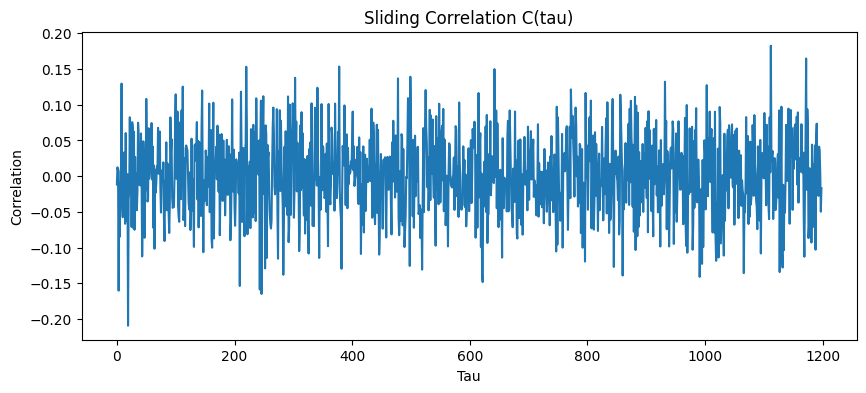

In [36]:
# Generate data
r, true_sw, true_offset = generate_dataset(L=500, Ls=64, K=200, snr_db=-5)

# Compute correlation
C = sliding_correlation(r, tau_max=1200, window_size=2000)

# Estimate frame length
L_est = estimate_frame_length_v2(C)

print("Estimated Frame Length:", L_est)


plt.figure(figsize=(10,4))
plt.plot(C)
plt.title("Sliding Correlation C(tau)")
plt.xlabel("Tau")
plt.ylabel("Correlation")
plt.show()


## 4. Periodic Averaging to Recover SW


In [30]:
def periodic_average(r, L_est):
    """
    Average samples separated by L_est.
    """
    K = len(r) // L_est
    avg = np.zeros(L_est)
    
    for k in range(K):
        avg += r[k*L_est:(k+1)*L_est]
        
    return avg / K


Averaged Signal Shape: (1,)


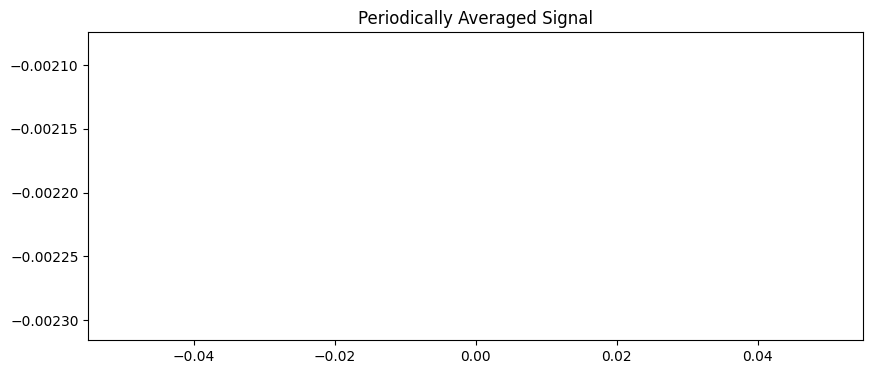

In [31]:
avg_signal = periodic_average(r, L_est)
print("Averaged Signal Shape:", avg_signal.shape)

plt.figure(figsize=(10,4))
plt.plot(avg_signal)
plt.title("Periodically Averaged Signal")
plt.show()


## 5. Algorithm 2: Improved Estimation


In [32]:
# 5.1 Adaptive Thresholding
def threshold_peaks(C, alpha=0.7):
    threshold = alpha * np.max(C)
    return np.where(C > threshold)[0]

# 5.2 Edge Detection on Averaged Signal
def edge_detection(avg_signal):
    return np.abs(np.diff(avg_signal))

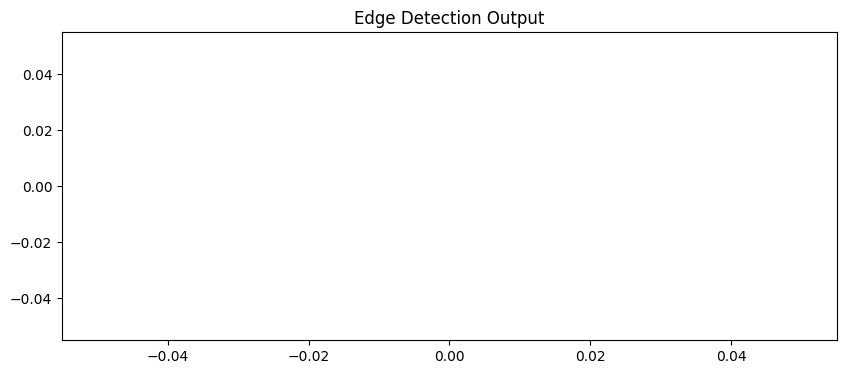

In [33]:
edges = edge_detection(avg_signal)

plt.figure(figsize=(10,4))
plt.plot(edges)
plt.title("Edge Detection Output")
plt.show()


## 6. Parameter Sensitivity Analysis


In [35]:
snr_values = [0, 5, 10, 15, 20]
results = []

for snr in snr_values:
    r, _ = generate_dataset(L=500, Ls=64, K=200, snr_db=-5)
    C = sliding_correlation(r, tau_max=300, window_size=2000)
    L_est = estimate_frame_length_v2(C)
    results.append(L_est)

print(list(zip(snr_values, results)))


ValueError: too many values to unpack (expected 2)